In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [4]:
from src.utils.config import PROCESSED_DATA_DIR
import pandas as pd

df = pd.read_parquet(PROCESSED_DATA_DIR / "team_match_features.parquet")

print(df.shape)
df.head()

(98142, 24)


,date,team_a,team_b,goals_a,goals_b,tournament,city,country,neutral_venue,year,...,goals_against,win,draw,loss,points,rolling_goals_scored,rolling_goals_conceded,rolling_goal_diff,rolling_win_rate,rolling_points
0,2012-09-25,Abkhazia,Artsakh,1,1,Friendly,Sukhumi,Georgia,False,2012,...,1,0,1,0,1,NaN,NaN,NaN,NaN,NaN
1,2012-10-21,Artsakh,Abkhazia,3,0,Friendly,Stepanakert,Azerbaijan,False,2012,...,3,0,0,1,0,NaN,NaN,NaN,NaN,NaN
2,2014-06-01,Abkhazia,Occitania,1,1,CONIFA World Football Cup,Östersund,Sweden,True,2014,...,1,0,1,0,1,NaN,NaN,NaN,NaN,NaN
3,2014-06-02,Sápmi,Abkhazia,1,2,CONIFA World Football Cup,Östersund,Sweden,False,2014,...,1,1,0,0,3,NaN,NaN,NaN,NaN,NaN
4,2014-06-04,Abkhazia,South Ossetia,0,0,CONIFA World Football Cup,Östersund,Sweden,True,2014,...,0,0,1,0,1,NaN,NaN,NaN,NaN,NaN


In [5]:
df["team"].nunique()

333

In [6]:
teams = sorted(df["team"].unique())

teams[:50]

['Abkhazia',
 'Afghanistan',
 'Albania',
 'Alderney',
 'Algeria',
 'Ambazonia',
 'American Samoa',
 'Andalusia',
 'Andorra',
 'Angola',
 'Anguilla',
 'Antigua and Barbuda',
 'Arameans Suryoye',
 'Argentina',
 'Armenia',
 'Artsakh',
 'Aruba',
 'Asturias',
 'Australia',
 'Austria',
 'Aymara',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barawa',
 'Barbados',
 'Basque Country',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Biafra',
 'Bolivia',
 'Bonaire',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'British Virgin Islands',
 'Brittany',
 'Brunei',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Canary Islands']

In [7]:
df["team"].value_counts().head(20)

team
Sweden         1097
England        1086
Argentina      1062
Brazil         1055
Germany        1027
South Korea    1003
Hungary        1002
Mexico          997
Uruguay         966
France          931
Italy           889
Poland          888
Switzerland     880
Netherlands     875
Denmark         870
Norway          868
Thailand        863
Austria         857
Belgium         849
Scotland        847
Name: count, dtype: int64

In [8]:
df["tournament"].value_counts().head(20)

tournament
Friendly                                36362
FIFA World Cup qualification            17510
UEFA Euro qualification                  5648
African Cup of Nations qualification     4654
FIFA World Cup                           1928
Copa América                             1738
African Cup of Nations                   1690
AFC Asian Cup qualification              1658
UEFA Nations League                      1316
CECAFA Cup                               1240
CFU Caribbean Cup qualification          1212
Merdeka Tournament                       1198
British Home Championship                1046
CONCACAF Nations League                   844
AFC Asian Cup                             842
Gold Cup                                  840
Gulf Cup                                  820
Island Games                              788
UEFA Euro                                 776
Asian Games                               736
Name: count, dtype: int64

<Axes: xlabel='date'>

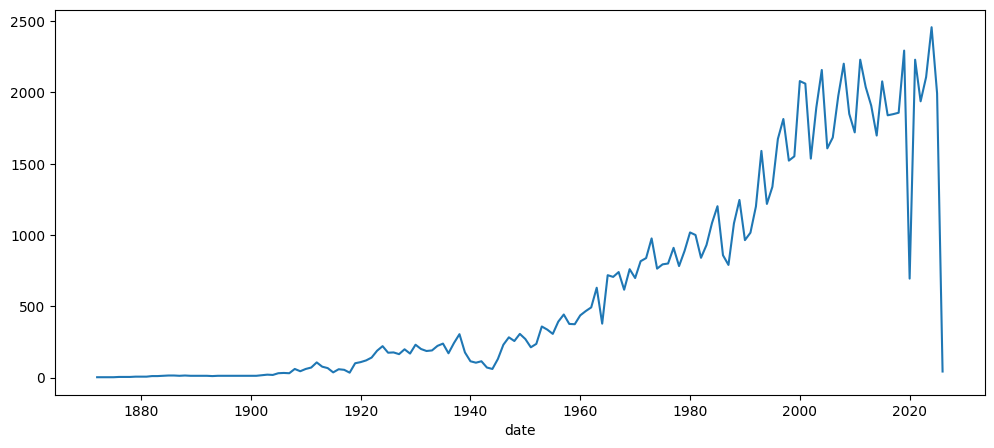

In [9]:
df.groupby(df["date"].dt.year).size().plot(figsize=(12,5))

In [10]:
import sys
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.utils.config import PROCESSED_DATA_DIR

df = pd.read_parquet(PROCESSED_DATA_DIR / "matches_filtered.parquet")

print(df.shape)
print(df["team"].nunique())
print(df["tournament"].value_counts().head(20))
print(sorted(df["team"].unique())[:50])

(62959, 24)
185
tournament
Friendly                                26765
FIFA World Cup qualification            14790
UEFA Euro qualification                  4794
African Cup of Nations qualification     3798
FIFA World Cup                           1658
AFC Asian Cup qualification              1339
African Cup of Nations                   1270
Copa América                             1262
UEFA Nations League                      1128
AFC Asian Cup                             792
UEFA Euro                                 720
Gold Cup                                  716
COSAFA Cup                                602
CFU Caribbean Cup qualification           393
CONCACAF Nations League                   380
SAFF Cup                                  324
UNCAF Cup                                 322
Arab Cup                                  305
CONCACAF Championship                     296
Confederations Cup                        270
Name: count, dtype: int64
['Afghanistan', 'Albania', 

In [11]:
df = pd.read_parquet(PROCESSED_DATA_DIR / "matches_filtered.parquet")

print(df.shape)
print(df["team"].nunique())
print(df["tournament"].value_counts().head(10))

(62959, 24)
185
tournament
Friendly                                26765
FIFA World Cup qualification            14790
UEFA Euro qualification                  4794
African Cup of Nations qualification     3798
FIFA World Cup                           1658
AFC Asian Cup qualification              1339
African Cup of Nations                   1270
Copa América                             1262
UEFA Nations League                      1128
AFC Asian Cup                             792
Name: count, dtype: int64


In [12]:
import sys
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.utils.config import PROCESSED_DATA_DIR

elo = pd.read_parquet(PROCESSED_DATA_DIR / "team_elo_ratings.parquet")

print(elo.shape)
elo.head()

(63404, 17)


,date,team,opponent,tournament,neutral_venue,goals_for,goals_against,actual_result,expected_result,k_factor,goal_diff_multiplier,elo_before,elo_after,opponent_elo_before,opponent_elo_after,elo_change,elo_diff_before
0,1950-02-17,Egypt,Greece,Friendly,False,2,0,1.0,0.613137,20.0,1.50,1500.0,1511.605895,1500.0,1488.394105,11.605895,0.0
1,1950-02-17,Greece,Egypt,Friendly,False,0,2,0.0,0.386863,20.0,1.50,1500.0,1488.394105,1500.0,1511.605895,-11.605895,0.0
2,1950-02-26,Bolivia,Chile,Friendly,False,2,0,1.0,0.613137,20.0,1.50,1500.0,1511.605895,1500.0,1488.394105,11.605895,0.0
3,1950-02-26,Chile,Bolivia,Friendly,False,0,2,0.0,0.386863,20.0,1.50,1500.0,1488.394105,1500.0,1511.605895,-11.605895,0.0
4,1950-02-26,Croatia,Serbia,Friendly,False,4,1,1.0,0.613137,20.0,1.75,1500.0,1513.540211,1500.0,1486.459789,13.540211,0.0


In [13]:
elo.groupby("team")["elo_after"].last().sort_values(ascending=False).head(20)

team
Spain          2118.252512
Argentina      2087.572430
France         2025.410495
Colombia       1986.071381
Portugal       1985.480784
England        1983.499181
Brazil         1977.755639
Netherlands    1934.797528
Senegal        1927.200545
Ecuador        1906.317066
Germany        1900.019766
Croatia        1895.502471
Uruguay        1891.728983
Switzerland    1879.394914
Morocco        1874.002074
Japan          1870.879335
Italy          1859.714881
Norway         1851.802354
Mexico         1847.003648
Turkey         1843.421477
Name: elo_after, dtype: float64

In [14]:
elo[elo["team"] == "Spain"][["date", "elo_after"]].tail(20)

,date,elo_after
60946,2024-06-30,2034.439780
60970,2024-07-05,2052.984625
60983,2024-07-09,2071.348342
60993,2024-07-14,2085.625693
61060,2024-09-05,2075.788084
61158,2024-09-08,2095.367635
61412,2024-10-12,2100.036657
61540,2024-10-15,2106.285476
61665,2024-11-15,2115.531631
61755,2024-11-18,2118.998449


<Axes: title={'center': 'Argentina Elo Rating Over Time'}, xlabel='date'>

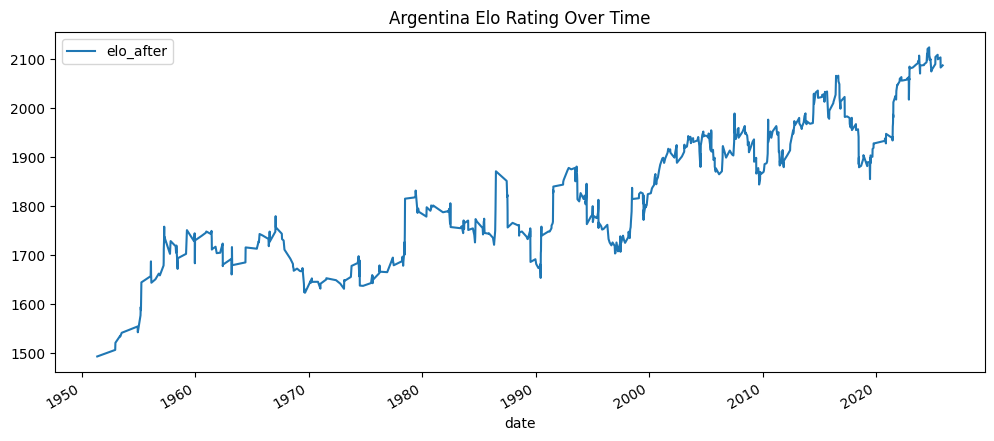

In [15]:
team = "Argentina"
team_elo = elo[elo["team"] == team].sort_values("date")

team_elo.plot(x="date", y="elo_after", figsize=(12, 5), title=f"{team} Elo Rating Over Time")

In [16]:
elo.groupby("team")["elo_after"].last().sort_values(ascending=False).head(20)

team
Spain          2118.252512
Argentina      2087.572430
France         2025.410495
Colombia       1986.071381
Portugal       1985.480784
England        1983.499181
Brazil         1977.755639
Netherlands    1934.797528
Senegal        1927.200545
Ecuador        1906.317066
Germany        1900.019766
Croatia        1895.502471
Uruguay        1891.728983
Switzerland    1879.394914
Morocco        1874.002074
Japan          1870.879335
Italy          1859.714881
Norway         1851.802354
Mexico         1847.003648
Turkey         1843.421477
Name: elo_after, dtype: float64

In [17]:
[t for t in teams if "United" in t]
[t for t in teams if "Korea" in t]
[t for t in teams if "Morocco" in t]
[t for t in teams if "Netherlands" in t]
[t for t in teams if "Nigeria" in t]
[t for t in teams if "Peru" in t]
[t for t in teams if "Portugal" in t]
[t for t in teams if "Senegal" in t]
[t for t in teams if "Serbia" in t]
[t for t in teams if "Switzerland" in t]
[t for t in teams if "Turkey" in t]
[t for t in teams if "Uruguay" in t]
[t for t in teams if "USA" in t]

[]

In [19]:
from pathlib import Path
import json

PROJECT_ROOT = Path.cwd().resolve().parents[0]

groups_path = PROJECT_ROOT / "configs" / "world_cup_groups.json"

with open(groups_path, "r", encoding="utf-8") as f:
    groups = json.load(f)

print(groups_path)

C:\Users\manue\Projects\world-cup-2026-forecast\configs\world_cup_groups.json


In [21]:
available = set(teams)

missing = []

for group_name, group_teams in groups.items():
    for team in group_teams:
        if team not in available:
            missing.append((group_name, team))

missing

[('B', 'USA'), ('D', 'Korea Republic')]

In [22]:
for group, team in missing:
    print(group, "->", team)

B -> USA
D -> Korea Republic
